## Analysis of Transient Candidate Signals

## Data Import

In [1]:
import numpy as np
from matplotlib import cm
from intf import intf
import h5py
import os
from scipy import signal
from scipy.signal import welch
from scipy.signal import find_peaks
from scipy.signal import peak_prominences
from scipy.fft import fft, ifft
from scipy.integrate import cumtrapz
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from pylab import *
plt.style.use('classic')
mpl.rc("figure", facecolor="white")

In [2]:
run0_GEN1b = 'C:/Users/21958742/DarkMatterCentre Dropbox/William Campbell/PhD/High Frequency GW/Data Analysis/4k GEN1b/run0'
run4_GEN2HG = 'C:/Users/21958742/DarkMatterCentre Dropbox/William Campbell/PhD/High Frequency GW/Data Analysis/4k GEN2HG/run4'

Parameters

In [3]:
#lock-in reference frequencies
f_lockin_run0_5C = 8.392106E+6 + 1.9
f_lockin_run0_3B = 5.505658500E+6 - 2.8
f_lockin_run4_3C = 4.993017E+6 
f_lockin_run4_3B = 5.5056586E+6

#mode frequencies
w_run0_5C = f_lockin_run0_5C*np.pi*2
w_run0_3B = f_lockin_run0_3B*np.pi*2
w_run4_3C = f_lockin_run4_3C*np.pi*2
w_run4_3B = f_lockin_run4_3B*np.pi*2
#electromechanical coupling parameters
kappa_3C = 0.00164284
kappa_3B = 0.00155445
kappa_5C = 0.00106269

#Squid transimpedance from MMCA Notebook
Zsquid_5C = 257604
Zsquid_3B = 363360
Zsquid_3C = 396523.297
Zsquid_run0_3B = 363360
# Q factors from Nyquist limit paper
Q_5C = 10.7E7
Q_3B = 1.5E7
Q_3C = 3.7E7
# Measured Q factors
Q_3B = 4.2E7
Q_3C = 4.2E7

tau0_5C = Q_5C/w_run0_5C
tau0_3B = Q_3B/w_run0_3B
tau0_3C = Q_3C/w_run4_3C
#time step
dt=0.01

#reference signal RMS voltage
Vr = 600.0E-3/(np.sqrt(2)*2)

h0=0.0005
trap=0.848
H0=2.2*10**(-18)
kb = 1.38064852E-23


In [4]:
f_run0 = h5py.File(run0_GEN1b + '/run0.hdf5','r')
f_run4 = h5py.File(run4_GEN2HG + '/run4.hdf5','r')

In [5]:
1/tau0_3B, 1/tau0_3C, 1/tau0_5C

(0.8236441666816557, 0.746953596497569, 0.49279597246304424)

## Decay Fitting

In [6]:
span = 450

#signal 1
nn = 33018858
#signal 2
nn_2 = 13483371
#signal 3
nn_3 = 13569391

sig1_1X = f_run0['1X/Data'][nn-span:span+nn]
sig1_1Y = f_run0['1Y/Data'][nn-span:span+nn]
sig1_2X = f_run0['2X/Data'][nn-span:span+nn]
sig1_2Y = f_run0['2Y/Data'][nn-span:span+nn]

sig2_1X = f_run4['1X/Data'][nn_2-span:span+nn_2]
sig2_1Y = f_run4['1Y/Data'][nn_2-span:span+nn_2]
sig2_2X = f_run4['2X/Data'][nn_2-span:span+nn_2]
sig2_2Y = f_run4['2Y/Data'][nn_2-span:span+nn_2]

sig3_1X = f_run4['1X/Data'][nn_3-span:span+nn_3]
sig3_1Y = f_run4['1Y/Data'][nn_3-span:span+nn_3]
sig3_2X = f_run4['2X/Data'][nn_3-span:span+nn_3]
sig3_2Y = f_run4['2Y/Data'][nn_3-span:span+nn_3]

#filter off DC offset output by the lock-ins mixer
sig1_1X-=np.mean(sig1_1X)
sig1_1Y-=np.mean(sig1_1Y)
sig1_2X-=np.mean(sig1_2X)
sig1_2Y-=np.mean(sig1_2Y)

sig2_1X-=np.mean(sig2_1X)
sig2_1Y-=np.mean(sig2_1Y)
sig2_2X-=np.mean(sig2_2X)
sig2_2Y-=np.mean(sig2_2Y)

sig3_1X-=np.mean(sig3_1X)
sig3_1Y-=np.mean(sig3_1Y)
sig3_2X-=np.mean(sig3_2X)
sig3_2Y-=np.mean(sig3_2Y)

#rms magnitude of lockin input signal (post gain-stage)
sig1_1R = np.sqrt(sig1_1X**2+sig1_1Y**2)
sig1_2R = np.sqrt(sig1_2X**2+sig1_2Y**2)

sig2_1R = np.sqrt(sig2_1X**2+sig2_1Y**2)
sig2_2R = np.sqrt(sig2_2X**2+sig2_2Y**2)

sig3_1R = np.sqrt(sig3_1X**2+sig3_1Y**2)
sig3_2R = np.sqrt(sig3_2X**2+sig3_2Y**2)

tn = np.linspace(0,len(sig1_1X)*dt,len(sig1_1X))

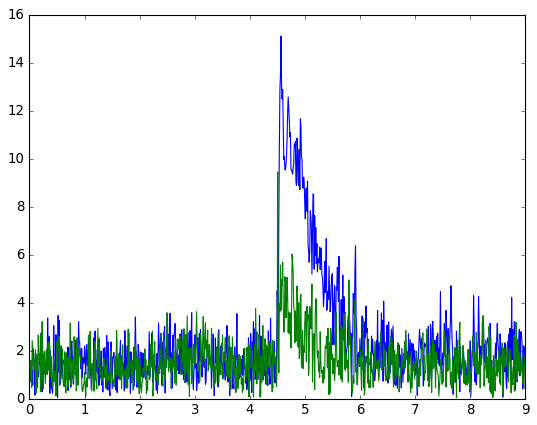

In [7]:
# plt.plot(tn,sig1_ch2)
# plt.plot(tn,sig1_2Y)
# plt.plot(tn,sig1_2Y)
plt.plot(tn,sig2_2R)
plt.plot(tn,sig2_1R)

We want to fit time constants to the magnitude signal downconverted from the noise peak i.e. DC signal corresponding to thermal noise in the mode

Signal is taken from output of lock-in amplifier demodulated to the $f_\mathrm{ref}$ and has unit of $\mu$V

Lock-in amplifier set to full 10V range sensitivity of 10$\mu$V and $\tau_\mathrm{lock} = 0.003s$ has transfer function

$$H_\mathrm{lock}(\omega)=\frac{10^6}{\tau_\mathrm{lock}\omega+1}$$

We take the fourier transform of the input signal and divide by the lock-in transfer function to get the pre filtered input signal 

$$Y(\omega)=\mathcal{F}\{y(t)\}$$
$$x(t)=\mathcal{F}^{-1}\{\frac{Y(\omega)}{H(\omega)}\}$$

where $y(t)$ is the magnitude of lock-in output signal in units of $\mu$Vrms then $x(t)$ is the magnitude of the input signal to the lock demodulated at $f_\mathrm{ref}$

$x(t)$ is then the voltage signal at the SQUID output demodulated from $f_\mathrm{ref}$, we get the magnitude of the current signal on at the SQUID input by
$$I(t) = \frac{|x(t)|}{Z_\mathrm{SQUID}}$$

Dividing this current signal by the electromechanical coupling constant which has units of $\frac{C}{m}$ gives the magnitude of the crystal's velocity $\dot{u}(x)$ downconverted form $f_\mathrm{ref}$

We then numerically integrate the signal $\dot{u}(t)$ via fourier method to derrive the estimated displacement magnitude downconverted from $f_\mathrm{ref}$


In [8]:
tau_lockin = 0.003
T = dt
N = len(tn)
fn = np.linspace(0,1/(2*T),N)

#lockin transfer function
H_lockin = 10**6#/(tau_lockin/0.644*fn*2j*np.pi+1)
#Fourier domain output signal
Yw1_2R = fft(sig1_2R)
Yw1_1R = fft(sig1_1R)

Yw2_2R = fft(sig2_2R)
Yw2_1R = fft(sig2_1R)

Yw3_2R = fft(sig3_2R)
Yw3_1R = fft(sig3_1R)
#fourier domain input signal

Xw1_2R = Yw1_2R/H_lockin
Xw1_1R = Yw1_1R/H_lockin

Xw2_2R = Yw2_2R/H_lockin
Xw2_1R = Yw2_1R/H_lockin

Xw3_2R = Yw3_2R/H_lockin
Xw3_1R = Yw3_1R/H_lockin
#lockin modulated mixer output signal in Volts RMS

Xt1_1R = ifft(Xw1_1R)
Xt1_2R = ifft(Xw1_2R)

Xt2_1R = ifft(Xw2_1R)
Xt2_2R = ifft(Xw2_2R)

Xt3_1R = ifft(Xw3_1R)
Xt3_2R = ifft(Xw3_2R)
#current modulation signal at input of SQUID

I1_1R = np.abs(Xt1_1R)/Zsquid_5C
I1_2R = np.abs(Xt1_2R)/Zsquid_run0_3B

I2_1R = np.abs(Xt2_1R)/Zsquid_3C
I2_2R = np.abs(Xt2_2R)/Zsquid_3B

I3_1R = np.abs(Xt3_1R)/Zsquid_3C
I3_2R = np.abs(Xt3_2R)/Zsquid_3B
#velocity modulation signal output by quartz crystal

u_dot1_1R = I1_1R/kappa_5C
u_dot1_2R = I1_2R/kappa_3B

u_dot2_1R = I2_1R/kappa_3C
u_dot2_2R = I2_2R/kappa_3B

u_dot3_1R = I3_1R/kappa_3C
u_dot3_2R = I3_2R/kappa_3B


#dsiplacement signal by fourier integration
u1_2R_intf = intf(u_dot1_2R, 100.0, f_lo=0.0, f_hi=50.0, times=1, winlen=1, unwin=False, demod_freq = f_lockin_run0_3B, zero_mean=True) 
u1_1R_intf = intf(u_dot1_1R, 100.0, f_lo=0.0, f_hi=50.0, times=1, winlen=1, unwin=False, demod_freq = f_lockin_run0_5C, zero_mean=True)

u2_2R_intf = intf(u_dot2_2R, 100.0, f_lo=0.0, f_hi=50.0, times=1, winlen=1, unwin=False, demod_freq = f_lockin_run4_3B, zero_mean=True)
u2_1R_intf = intf(u_dot2_1R, 100.0, f_lo=0.0, f_hi=50.0, times=1, winlen=1, unwin=False, demod_freq = f_lockin_run4_3C, zero_mean=True)

u3_2R_intf = intf(u_dot3_2R, 100.0, f_lo=0.0, f_hi=50.0, times=1, winlen=1, unwin=False, demod_freq = f_lockin_run4_3B, zero_mean=True)
u3_1R_intf = intf(u_dot3_1R, 100.0, f_lo=0.0, f_hi=50.0, times=1, winlen=1, unwin=False, demod_freq = f_lockin_run4_3C, zero_mean=True)

#displacement signal by cumulative trapezial integration
tau = 1
filt = signal.lti([tau,0],[tau,1])
u_dot1_2R_filt = signal.lsim(filt, u_dot1_2R, tn)[1]

u1_2R_trapz = cumtrapz(u_dot1_2R_filt, tn, initial = 0.0)

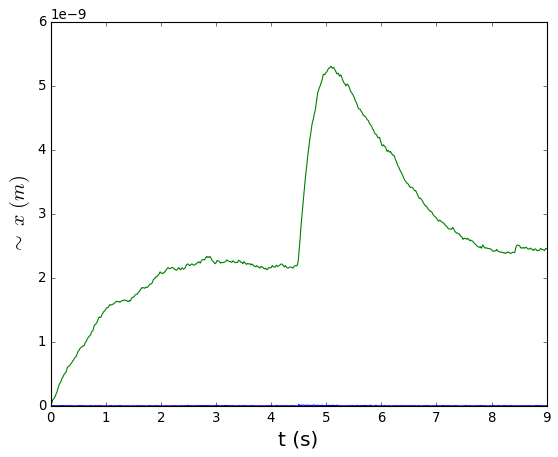

In [13]:
#Magnitude of displacement estimated by fourier intergrating
fig,ax = plt.subplots(1,sharey=True)
ax.plot(tn,(I2_1R),label=r'5.505 MHz Mode', linestyle=('-'))
ax.plot(tn,(u1_2R_trapz),label=r'5.505 MHz Mode', linestyle=('-'))
ax.set_xlabel(r't (s)',fontsize=18)
ax.set_ylabel(r'$\sim~x~(m)$',fontsize=18)
plt.show()

We fit the function $A_0 e^{\frac{-t}{\tau}}$ to the current signal 

In [17]:
#time constant fitting model
def f_exp(t,A0,tau,c):
    return A0*np.exp(-t/tau)+c

def f_exp2(t,A0,tau):
    return A0*np.exp(-t/tau)


In [18]:
#sample space fitting parameters
cutoff_1 = np.where(I1_1R == np.max(I1_1R))[0][0]
cutoff_2 = np.where(I1_2R == np.max(I1_2R))[0][0]

fit_span = 100
stop_1 = cutoff_1 + fit_span
stop_2 = cutoff_2 + fit_span

In [19]:
#initial conditions for fit
ini_params=[1.2E-11,1,0.0]

tau_fit1 = curve_fit(f_exp,tn[cutoff_1:stop_1]-tn[cutoff_1],I1_1R[cutoff_1:stop_1],p0=ini_params)
tau_fit2 = curve_fit(f_exp,tn[cutoff_2:stop_2]-tn[cutoff_2],I1_2R[cutoff_2:stop_2],p0=ini_params)

C:\Users\21958742\Anaconda3\lib\site-packages\ipykernel_launcher.py:3: RuntimeWarning: overflow encountered in exp
  This is separate from the ipykernel package so we can avoid doing imports until
C:\Users\21958742\Anaconda3\lib\site-packages\scipy\optimize\minpack.py:808: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)


In [20]:
#fitting loop
for i in range(1000):
    new_fit_params1 = tau_fit1[0]
    new_fit_params2 = tau_fit2[0]
    
    tau_fit1 = curve_fit(f_exp,tn[cutoff_1:stop_1]-tn[cutoff_1],I1_1R[cutoff_1:stop_1],p0=new_fit_params1)
    tau_fit2 = curve_fit(f_exp,tn[cutoff_2:stop_2]-tn[cutoff_2],I1_2R[cutoff_2:stop_2],p0=new_fit_params2)

In [21]:
fit_data_ch1=f_exp(tn[cutoff_1:stop_1]-tn[cutoff_1],tau_fit1[0][0],tau_fit1[0][1],tau_fit1[0][2])
fit_data_ch2=f_exp(tn[cutoff_2:stop_2]-tn[cutoff_2],tau_fit2[0][0],tau_fit2[0][1],tau_fit2[0][2])

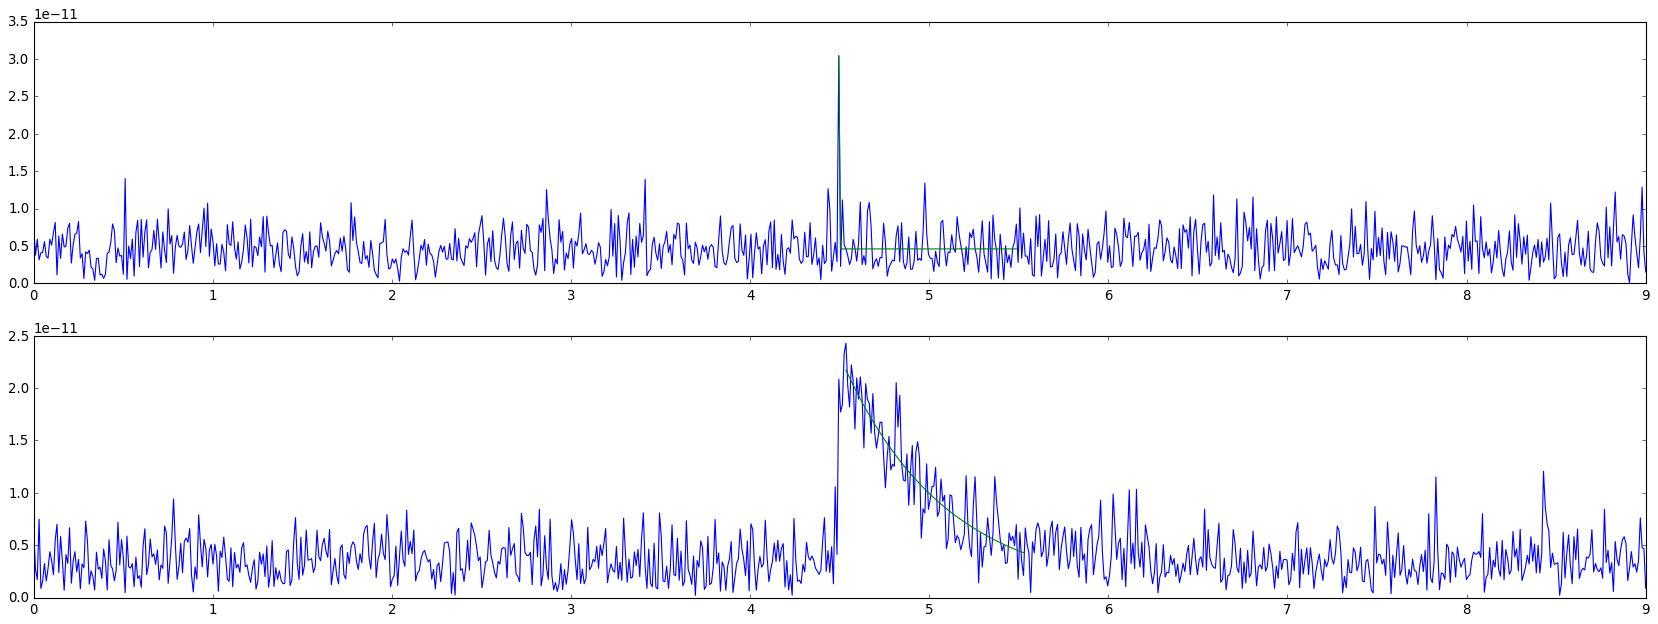

In [22]:
fig,ax = plt.subplots(2,figsize=(26,9),sharey=False)
ax[0].plot(tn,I1_1R,label=r'4.993 MHz Mode')
ax[0].plot(tn[cutoff_1:stop_1],fit_data_ch1)

ax[1].plot(tn,I1_2R,label=r'5.505 MHz Mode')
ax[1].plot(tn[cutoff_2:stop_2],fit_data_ch2)

plt.show()

In [23]:
tau_fit1[0]

array([2.57968240e-11, 1.82553231e-04, 4.60691921e-12])

In [24]:
tau_fit2[0]

array([2.12047150e-11, 5.72598956e-01, 5.28884493e-13])

In [25]:
tau1_1 = tau_fit1[0][1]
tau1_2 = tau_fit2[0][1]

In [26]:
#sample space fitting parameters
cutoff_1 = np.where(I2_1R == np.max(I2_1R))[0][0]
cutoff_2 = np.where(I2_2R == np.max(I2_2R))[0][0]



fit_span = 150
stop_1 = cutoff_1 + fit_span
stop_2 = cutoff_2 + fit_span

In [27]:
#initial conditions for fit
ini_params=[1.2E-11,1,0.0]

tau_fit1 = curve_fit(f_exp,tn[cutoff_1:stop_1]-tn[cutoff_1],I2_1R[cutoff_1:stop_1],p0=ini_params)
tau_fit2 = curve_fit(f_exp,tn[cutoff_2:stop_2]-tn[cutoff_2],I2_2R[cutoff_2:stop_2],p0=ini_params)

In [28]:
#fitting loop
for i in range(1000):
    new_fit_params1 = tau_fit1[0]
    new_fit_params2 = tau_fit2[0]
    
    tau_fit1 = curve_fit(f_exp,tn[cutoff_1:stop_1]-tn[cutoff_1],I2_1R[cutoff_1:stop_1],p0=new_fit_params1)
    tau_fit2 = curve_fit(f_exp,tn[cutoff_2:stop_2]-tn[cutoff_2],I2_2R[cutoff_2:stop_2],p0=new_fit_params2)

In [29]:
fit_data_ch1=f_exp(tn[cutoff_1:stop_1]-tn[cutoff_1],tau_fit1[0][0],tau_fit1[0][1],tau_fit1[0][2])
fit_data_ch2=f_exp(tn[cutoff_2:stop_2]-tn[cutoff_2],tau_fit2[0][0],tau_fit2[0][1],tau_fit2[0][2])

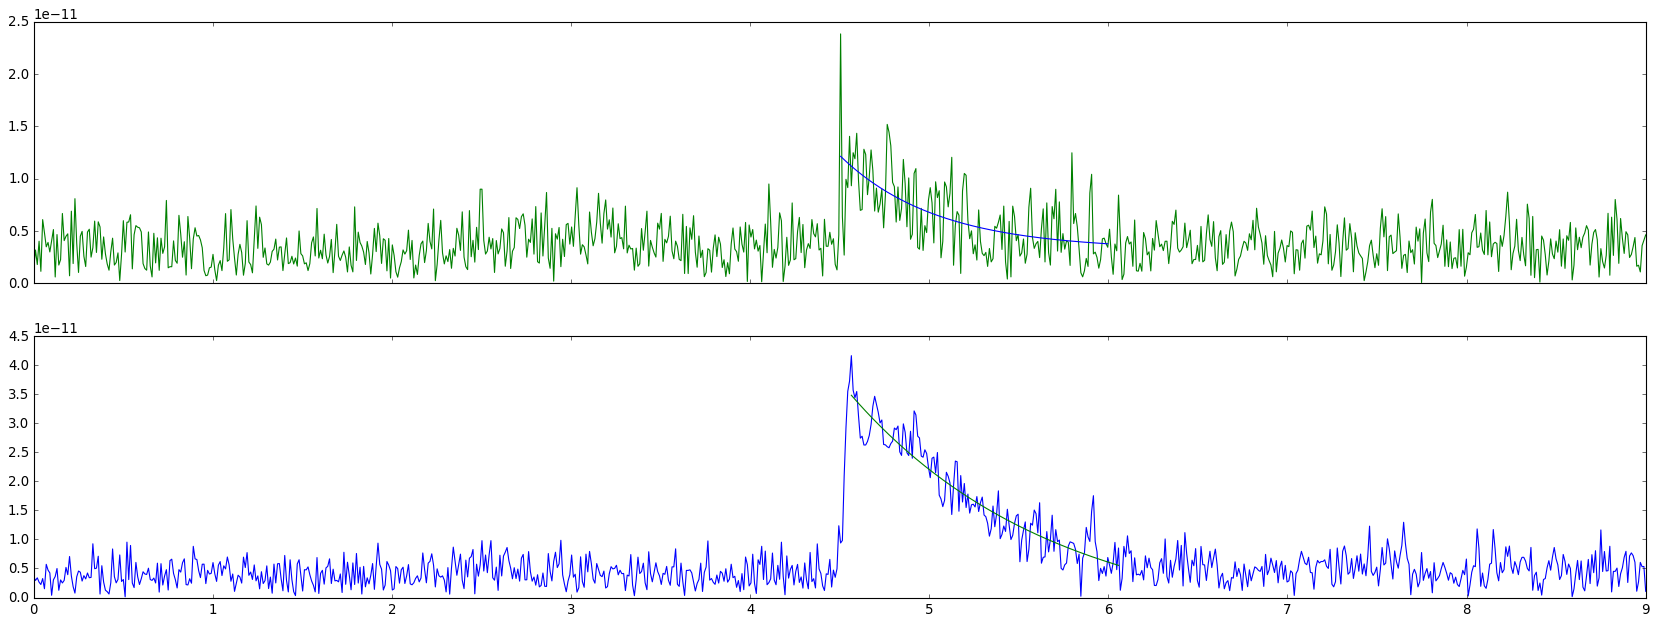

In [30]:
fig,ax = plt.subplots(2,figsize=(26,9),sharex=True)
ax[0].plot(tn,I2_1R,label=r'4.993 MHz Mode',color='green')
ax[0].plot(tn[cutoff_1:stop_1],fit_data_ch1)

ax[1].plot(tn,I2_2R,label=r'5.505 MHz Mode')
ax[1].plot(tn[cutoff_2:stop_2],fit_data_ch2)

ax[0].set_xlim(tn[0],tn[-1])

plt.show()

In [31]:
tau_fit1[0]

array([8.91247658e-12, 5.39347370e-01, 3.21923125e-12])

In [32]:
tau_fit2[0]

array([ 3.98162683e-11,  1.12527245e+00, -5.04492151e-12])

In [33]:
tau2_1 = tau_fit1[0][1]
tau2_2 = tau_fit2[0][1]

These $\tau$ values seem a little low for amplitude decay, prehaps shouldn't fit to current signal. Energy decay time = 1/2 * amplitude decay time, energy should be related to $I(t)^2$. So we should expect something close to three seconds assuming Q = 4.4e+9


## Energy Calibration

Energy Deposit

In [15]:
#test sample of data with no events i.e. background

background_span = 9000000

#voltage time series taken up to 10 seconds before signal event for background noise
bckgnd1_2X = f_run0['2X/Data'][nn-1000-background_span:nn-1000]
bckgnd1_2Y = f_run0['2Y/Data'][nn-1000-background_span:nn-1000]

bckgnd2_2X = f_run4['2X/Data'][nn_2-1000-background_span:nn_2-1000]
bckgnd2_2Y = f_run4['2Y/Data'][nn_2-1000-background_span:nn_2-1000]

bckgnd2_1X = f_run4['1X/Data'][nn_2-1000-background_span:nn_2-1000]
bckgnd2_1Y = f_run4['1Y/Data'][nn_2-1000-background_span:nn_2-1000]

bckgnd1_2X-=np.mean(bckgnd1_2X)
bckgnd1_2Y-=np.mean(bckgnd1_2Y)

bckgnd2_2X-=np.mean(bckgnd2_2X)
bckgnd2_2Y-=np.mean(bckgnd2_2Y)

bckgnd2_1X-=np.mean(bckgnd2_1X)
bckgnd2_1Y-=np.mean(bckgnd2_1Y)

bckgnd1_2R  = np.sqrt(bckgnd1_2X**2+bckgnd1_2Y**2)

bckgnd2_2R = np.sqrt(bckgnd2_2X**2+bckgnd2_2Y**2)

bckgnd2_1R = np.sqrt(bckgnd2_1X**2+bckgnd2_1Y**2)

#arbitray time steps
tn = np.linspace(0,len(bckgnd1_2R)*dt,len(bckgnd1_2R))

Same process as described above excpet now we take a wider range of samples around the signal to get an estimate of the background noise

In [16]:
tau_lockin = 0.003
T = dt
N = len(tn)
fn = np.linspace(0,1/(2*T),N)

#lockin transfer function
H_lockin = 10**6#/(tau_lockin/0.644*fn*2j*np.pi+1)
#Fourier domain output signal
Yw1_2R = fft(bckgnd1_2R)
Yw2_2R = fft(bckgnd2_2R)
Yw2_1R = fft(bckgnd2_1R)

#fourier domain input signal
Xw1_2R = Yw1_2R/H_lockin
Xw2_1R = Yw2_1R/H_lockin
Xw2_2R = Yw2_2R/H_lockin

#lockin modulated mixer output signal in Volts RMS
Xt1_2R = ifft(Xw1_2R)
Xt2_1R = ifft(Xw2_1R)
Xt2_2R = ifft(Xw2_2R)

#current modulation signal at input of SQUID with transimpedance 1.2 M ohms
I_bck1_2R = np.abs(Xt1_2R)/Zsquid_run0_3B
I_bck2_1R = np.abs(Xt2_1R)/Zsquid_3B
I_bck2_2R = np.abs(Xt2_2R)/Zsquid_3B

#velocity modulation signal output by quartz crystal
u_dot_bck1_2R = I_bck1_2R/kappa_3B
u_dot_bck2_1R = I_bck2_1R/kappa_3B
u_dot_bck2_2R = I_bck2_2R/kappa_3B

#estimating displacement by fourier integration
ubck1_2R_intf = intf(u_dot_bck1_2R, 100.0, f_lo=0.0, f_hi=50.0, times=1, winlen=1, unwin=False, demod_freq = f_lockin_run0_3B, zero_mean=True)
ubck2_1R_intf = intf(u_dot_bck2_1R, 100.0, f_lo=0.0, f_hi=50.0, times=1, winlen=1, unwin=False, demod_freq = f_lockin_run4_3B, zero_mean=True)
ubck2_2R_intf = intf(u_dot_bck2_2R, 100.0, f_lo=0.0, f_hi=50.0, times=1, winlen=1, unwin=False, demod_freq = f_lockin_run4_3B, zero_mean=True)

In [17]:
np.mean(u_dot_bck1_2R)

2.2879882428439165e-09

In [36]:
kb = 1.38064852E-23
eV = 1.60218e-19
Tkelvin = 3.4

In [37]:
#actual calculated Mode mass of 3B mode
Mactual_3B = 8.508716769009257E-6
Mactual_3C = 0.000010839705197821956

In [38]:
#RMS amplitude of thermal fluctuation due to noise temperature (if at 3.4K)
np.sqrt(2*kb*437/(Mactual_3B*w_run4_3B**2))

1.088619482258032e-15

We check the mode temperature a few different ways.

1. Kip Thorne - Gravitation 

$$ \delta x = \xi = \mathcal{B}_n(t)e^{-i\omega_n t}u_n(x) $$

$$\left<E_\mathrm{vibration}\right> = 2\left<\frac{1}{2}\int\rho\dot{\xi}^2d^3x\right> = \frac{1}{2}M\omega_n^2\left<|\mathcal{B}_n|^2\right> = kT$$

Where $\mathcal{B}_n(t)$ is the mass-weighted average of the amplitudes of motion of the detectors mass elements

In [39]:
#Actual measured mean RMS amplitude fluctuation and corresponding mode temperature
Brms_meas1_ch2 = np.mean(np.abs(ubck1_2R_intf))
Brms_meas2_ch1 = np.mean(np.abs(ubck2_1R_intf))
Brms_meas2_ch2 = np.mean(np.abs(ubck2_2R_intf))


Mactual_3B*w_run4_3B**2*Brms_meas1_ch2**2/(2*kb),Mactual_3B*w_run4_3B**2*Brms_meas2_ch1**2/(2*kb),Mactual_3C*w_run4_3C**2*Brms_meas2_ch2**2/(2*kb)

(0.27817231508551155, 0.33349451907723926, 0.35390922847491985)

In [40]:
#estimating energy deposit from crystal displacement
Edep_disp1_2R = (np.max(np.abs(u1_2R_intf))-Brms_meas1_ch2)**2*0.5*Mactual_3B*w_run0_3B**2
Edep_disp2_1R = (np.max(np.abs(u2_1R_intf))-Brms_meas2_ch1)**2*0.5*Mactual_3C*w_run4_3C**2
Edep_disp2_2R = (np.max(np.abs(u2_2R_intf))-Brms_meas2_ch2)**2*0.5*Mactual_3B*w_run4_3B**2

norm = kb

Edep_disp1_2R/norm, Edep_disp2_1R/norm, Edep_disp2_2R/norm

(73.36718062733105, 45.09947223659911, 209.7098063855221)

Possible issues:

$\mathcal{B}_n(t)$ may not be exactly the measured amplitude of the crystal $x(t)$ at $\omega_n$

Inaccuracies in numerically integrating $\dot{x}(t)$

2. Impedance analysis
Current at the output of the quartz is $I(t)$, assuming we know the motional resistance of the crystal $R_n$, power dissipated should be
$$P(t) = I(t)^2R_n$$

Energy of the mode would then be

$$E(t) = I(t)^2R_n\tau_n$$

which when averaged should correspont to $kT$:

$$E_n = \left<|I(t)|^2\right>R_n\tau_n = kT$$

In [41]:
#Energy contained in current signal output by quartz of 3.0 Ohms motional resistance
R_3C = 3.0
R_3B = 2.9

E_imp1_ch2 = np.mean(I_bck1_2R**2)*R_3B*tau0_3B
E_imp2_ch1 = np.mean(I_bck2_1R**2)*R_3C*tau0_3C
E_imp2_ch2 = np.mean(I_bck2_2R**2)*R_3B*tau0_3B

norm = kb

E_imp1_ch2/norm, E_imp2_ch1/norm, E_imp2_ch2/norm

(4.107154708676698, 5.614351225560002, 4.9952344379856015)

In [42]:
#estimating energy despoit from impedence analysis
Edep_imp1_ch2 = np.max(I1_2R**2)*R_3B*tau0_3B - E_imp1_ch2
Edep_imp2_ch1 = np.max(I2_1R**2)*R_3C*tau0_3C - E_imp2_ch1
Edep_imp2_ch2 = np.max(I2_2R**2)*R_3B*tau0_3B - E_imp2_ch2

norm = kb

Edep_imp1_ch2/norm, Edep_imp2_ch1/norm, Edep_imp2_ch2/norm

(146.34744552808505, 159.43377944169944, 435.8124521387098)

In [82]:
np.sqrt((Edep_imp2_ch2)/(Mactual_3B*0.5*w_run4_3C**2))

1.198757767596378e-15

In [79]:
np.max(np.abs(u2_1R_intf))

3.71730459482448e-16

In [74]:
np.sqrt(4*kb/(Mactual_3B*0.5*w_run4_3B**2))

1.0415146412628987e-16

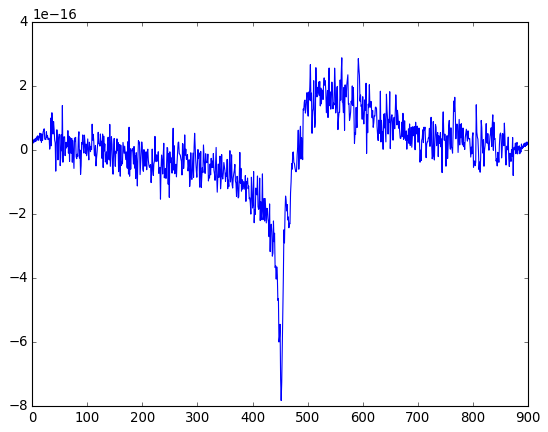

In [64]:
plt.plot(u2_2R_intf)

Possible issues:

If Q has changed over time potentially $\tau$ may not be what we expect, also $R_n$ was taken from nyquist observation paper, may not be what we expect

3. Kinetic energy of the crystal from its velocity

as $I(t) = \kappa_n\dot{u}(t)$ we can similarly calculate the average kinetic energy of the crystal by

$$E_n = \frac{1}{2}M_n\left<|\dot{u}(t)|^2\right> = \frac{1}{2}kT$$

In [14]:
#kinetic energy of each mode taken by assumed velocity of crystal

E_kin1_ch2 = np.mean(u_dot_bck1_2R**2)*Mactual_3B
E_kin2_ch1 = np.mean(u_dot_bck2_1R**2)*Mactual_3C
E_kin2_ch2 = np.mean(u_dot_bck2_2R**2)*Mactual_3B

norm = kb

E_kin1_ch2/norm, E_kin2_ch1/norm, E_kin2_ch2/norm

NameError: name 'u_dot_bck1_2R' is not defined

Possible Issues:

I dont't actually know if this expression is accurate, is the mean kinetic energy of the mode equal to $\frac{1}{2}kT$ ?

In [44]:
#kinetic energy deposited by each event

Edep_kin1_ch2 = np.max(u_dot1_2R**2)*Mactual_3B - E_kin1_ch2
Edep_kin2_ch1 = np.max(u_dot2_1R**2)*Mactual_3C - E_kin2_ch1
Edep_kin2_ch2 = np.max(u_dot2_2R**2)*Mactual_3B - E_kin2_ch2

norm = kb

Edep_kin1_ch2/norm, Edep_kin2_ch1/norm, Edep_kin2_ch2/norm

(146.3650307785209, 158.7768783471685, 435.86481978398217)

## Advanced fitting

The signal at the output of the lock-in amplifier is of the form

$$V_X(t) = V_I \mathrm{Sin}(2\pi f_\mathrm{r} t + \theta_\mathrm{r}-\theta_\mathrm{i})$$
$$V_Y(t) = V_I \mathrm{Cos}(2\pi f_\mathrm{r} t + \theta_\mathrm{r}-\theta_\mathrm{i})$$

We will fit the voltage noise output by lock-in a waveform $V_\mathrm{fit}(t) = V_0\mathrm{Sin}(2\pi f_r t + \theta)e^{-t/\tau}$ to find the time constant of amplitude decay

In [45]:
def Vfit(t,V0,fr,theta,tau):
    return V0*np.sin(2.0*np.pi*fr*t+theta)*np.exp(-t/tau)

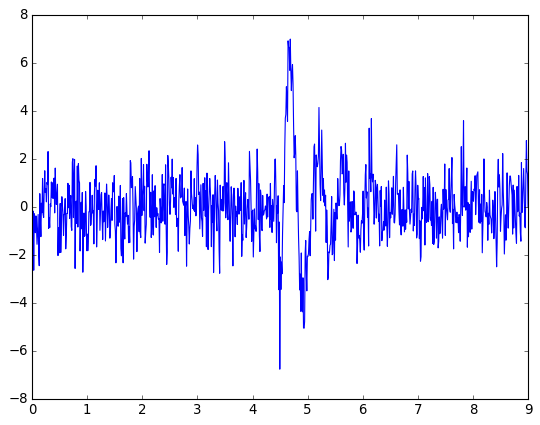

In [46]:
tn = tn = np.linspace(0,len(sig1_1X)*dt,len(sig1_1X))

plt.plot(tn,sig1_2X)

In [47]:
#finding demodulation frequencies by taking peak of PSD

#event 1 channel 2 5.5MHz
f_welch1_2X, S_welch1_2X = welch(bckgnd1_2X, fs=100.0, nperseg = len(bckgnd1_2X)//256)
fr1_2X=f_welch1_2X[list(S_welch1_2X).index(max(S_welch1_2X[3:]))]


fr1_ch2 = fr1_2X


#event 2 channel 1 4.993MHz
f_welch2_1X, S_welch2_1X = welch(bckgnd2_1X, fs=100.0, nperseg = len(bckgnd2_1X)//256)
fr2_1X=f_welch2_1X[list(S_welch2_1X).index(max(S_welch2_1X[3:]))]


fr2_ch1 = fr2_1X

#event 2 channel 2 5.505MHz
f_welch2_2X, S_welch2_2X = welch(bckgnd2_2X, fs=100.0, nperseg = len(bckgnd2_2X)//256)
fr2_2X=f_welch2_2X[list(S_welch2_2X).index(max(S_welch2_2X[3:]))]


fr2_ch2 = fr2_2X

In [48]:
#sample space fitting parameters
cutoff1_ch2 = np.where((sig1_2X) == np.max((sig1_2X)))[0][0]
cutoff2_ch1 = np.where((sig2_1X) == np.max((sig2_1X)))[0][0]
cutoff2_ch2 = np.where((sig2_2X) == np.max((sig2_2X)))[0][0]


fit_span = 200
stop1_ch2 = cutoff1_ch2 + fit_span
stop2_ch1 = cutoff2_ch1 + fit_span
stop2_ch2 = cutoff2_ch2 + fit_span 

In [49]:
#initial conditions for fit
ini_params1_ch2=[10.0,fr1_ch2,np.pi,3.0]
ini_params2_ch1=[10.0,fr2_ch1,np.pi,3.0]
ini_params2_ch2=[10.0,fr2_ch2,np.pi,3.0]

tau_fit1_ch2 = curve_fit(Vfit,tn[cutoff1_ch2:stop1_ch2]-tn[cutoff1_ch2],sig1_2X[cutoff1_ch2:stop1_ch2],p0=ini_params1_ch2)
tau_fit2_ch1 = curve_fit(Vfit,tn[cutoff2_ch1:stop2_ch1]-tn[cutoff2_ch1],sig2_1X[cutoff2_ch1:stop2_ch1],p0=ini_params2_ch1)
tau_fit2_ch2 = curve_fit(Vfit,tn[cutoff2_ch2:stop2_ch2]-tn[cutoff2_ch2],sig2_2X[cutoff2_ch2:stop2_ch2],p0=ini_params2_ch2)

fit_data1_ch2=Vfit(tn[cutoff1_ch2:stop1_ch2]-tn[cutoff1_ch2],tau_fit1_ch2[0][0],tau_fit1_ch2[0][1],tau_fit1_ch2[0][2],tau_fit1_ch2[0][3])
fit_data2_ch1=Vfit(tn[cutoff2_ch1:stop2_ch1]-tn[cutoff2_ch1],tau_fit2_ch1[0][0],tau_fit2_ch1[0][1],tau_fit2_ch1[0][2],tau_fit2_ch1[0][3])
fit_data2_ch2=Vfit(tn[cutoff2_ch2:stop2_ch2]-tn[cutoff2_ch2],tau_fit2_ch2[0][0],tau_fit2_ch2[0][1],tau_fit2_ch2[0][2],tau_fit2_ch2[0][3])

In [50]:
ideal_signal = Vfit(tn[cutoff2_ch2:stop2_ch2]-tn[cutoff2_ch2],6.0,fr2_ch2,0.7,3.0)

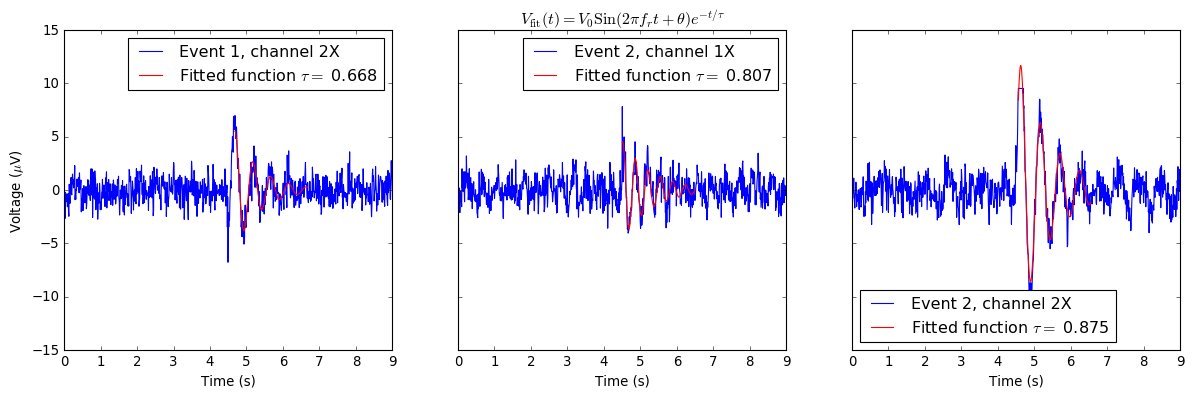

In [51]:
fig, ax = plt.subplots(1,3, figsize = (18,5),sharey=True)
ax[0].plot(tn,sig1_2X, label = 'Event 1, channel 2X')
ax[0].plot(tn[cutoff1_ch2:stop1_ch2],fit_data1_ch2,color = 'red', label = r'Fitted function $\tau =$ %1.3f' % tau_fit1_ch2[0][3])

ax[1].plot(tn,sig2_1X, label = 'Event 2, channel 1X')
ax[1].plot(tn[cutoff2_ch1:stop2_ch1],fit_data2_ch1,color = 'red', label = r'Fitted function $\tau =$ %1.3f' % tau_fit2_ch1[0][3])

ax[2].plot(tn,sig2_2X,label = 'Event 2, channel 2X')
ax[2].plot(tn[cutoff2_ch2:stop2_ch2],fit_data2_ch2,color = 'red',label = r'Fitted function $\tau =$ %1.3f' % tau_fit2_ch2[0][3])

# ax[2].plot(tn[cutoff2_ch2:stop2_ch2],ideal_signal, color = 'orange')

ax[1].set_title(r'$V_\mathrm{fit}(t) = V_0\mathrm{Sin}(2\pi f_r t + \theta)e^{-t/\tau}$')

ax[0].legend(loc=0)
ax[1].legend(loc=0)
ax[2].legend(loc=0)
ax[0].set_ylabel('Voltage ($\mu$V)')
ax[0].set_xlabel('Time (s)')
ax[1].set_xlabel('Time (s)')
ax[2].set_xlabel('Time (s)')

pp = r'C:/Users/21958742/DarkMatterCentre Dropbox/William Campbell/PhD/High Frequency GW/Data Analysis/Significant Events/taufit.pdf'
plt.savefig(pp, format='pdf', dpi=600)

In [52]:
tau_fit1_ch2[0][3],tau_fit2_ch1[0][3],tau_fit2_ch2[0][3]

(0.6683262745501136, 0.8067875290278518, 0.8748658861546397)

Now we try adding a second decay constant so that our signal takes the form 
$$V_\mathrm{fit}(t) = V_1\mathrm{Sin}(2\pi f_r t + \theta)e^{-t/\tau_1}+V_2\mathrm{Sin}(2\pi f_r t + \theta)e^{-t/\tau_2}$$

In [53]:
def Vfit_2decay(t,V1,V2,fr,theta,tau1,tau2,c):
    return V1*np.sin(2.0*np.pi*fr*t+theta)*np.exp(-t/tau1) + V2*np.sin(2.0*np.pi*fr*t+theta)*np.exp(-t/tau2) + c

In [54]:
ideal_signal2 = Vfit_2decay(tn[cutoff2_ch2:stop2_ch2]-tn[cutoff2_ch2], 4.0, 6.0, fr2_ch2, 0.7, 0.4,2.8,0.0)

In [55]:
#initial conditions for fit
ini_params1_ch2=[4.0,6.0,fr1_ch2,0.7,0.4,3.0,0.0]
ini_params2_ch1=[4.0,6.0,fr2_ch1,0.7,0.4,3.0,0.0]
ini_params2_ch2=[4.0,6.0,fr2_ch2,0.7,0.4,3.0,0.0]

tau_fit1_ch2 = curve_fit(Vfit_2decay,tn[cutoff1_ch2:stop1_ch2]-tn[cutoff1_ch2],sig1_2X[cutoff1_ch2:stop1_ch2],p0=ini_params1_ch2,  maxfev=10000)
tau_fit2_ch1 = curve_fit(Vfit_2decay,tn[cutoff2_ch1:stop2_ch1]-tn[cutoff2_ch1],sig2_1X[cutoff2_ch1:stop2_ch1],p0=ini_params2_ch1,  maxfev=10000)
tau_fit2_ch2 = curve_fit(Vfit_2decay,tn[cutoff2_ch2:stop2_ch2]-tn[cutoff2_ch2],sig2_2X[cutoff2_ch2:stop2_ch2],p0=ini_params2_ch2, maxfev=10000)

fit_data1_ch2=Vfit_2decay(tn[cutoff1_ch2:stop1_ch2]-tn[cutoff1_ch2],tau_fit1_ch2[0][0],tau_fit1_ch2[0][1],tau_fit1_ch2[0][2],tau_fit1_ch2[0][3],tau_fit1_ch2[0][4],tau_fit1_ch2[0][5],tau_fit1_ch2[0][6])
fit_data2_ch1=Vfit_2decay(tn[cutoff2_ch1:stop2_ch1]-tn[cutoff2_ch1],tau_fit2_ch1[0][0],tau_fit2_ch1[0][1],tau_fit2_ch1[0][2],tau_fit2_ch1[0][3],tau_fit2_ch1[0][4],tau_fit2_ch1[0][5],tau_fit2_ch1[0][6])
fit_data2_ch2=Vfit_2decay(tn[cutoff2_ch2:stop2_ch2]-tn[cutoff2_ch2],tau_fit2_ch2[0][0],tau_fit2_ch2[0][1],tau_fit2_ch2[0][2],tau_fit2_ch2[0][3],tau_fit2_ch2[0][4],tau_fit2_ch2[0][5],tau_fit2_ch2[0][6])

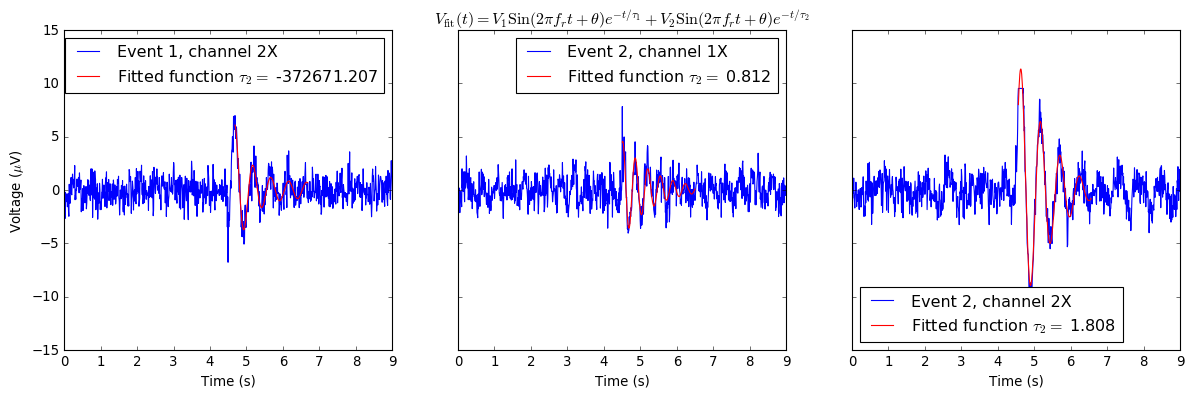

In [56]:
fig, ax = plt.subplots(1,3, figsize = (18,5),sharey=True)
ax[0].plot(tn,sig1_2X, label = 'Event 1, channel 2X')
ax[0].plot(tn[cutoff1_ch2:stop1_ch2],fit_data1_ch2,color = 'red', label = r'Fitted function $\tau_2 =$ %1.3f' % tau_fit1_ch2[0][5])

ax[1].plot(tn,sig2_1X, label = 'Event 2, channel 1X')
ax[1].plot(tn[cutoff2_ch1:stop2_ch1],fit_data2_ch1,color = 'red', label = r'Fitted function $\tau_2 =$ %1.3f' % tau_fit2_ch1[0][5])

ax[2].plot(tn,sig2_2X,label = 'Event 2, channel 2X')
ax[2].plot(tn[cutoff2_ch2:stop2_ch2],fit_data2_ch2,color = 'red',label = r'Fitted function $\tau_2 =$ %1.3f' % tau_fit2_ch2[0][5])

# ax[2].plot(tn[cutoff2_ch2:stop2_ch2],ideal_signal, color = 'orange')

ax[1].set_title(r'$V_\mathrm{fit}(t) = V_1\mathrm{Sin}(2\pi f_r t + \theta)e^{-t/\tau_1}+V_2\mathrm{Sin}(2\pi f_r t + \theta)e^{-t/\tau_2}$')

ax[0].legend(loc=0)
ax[1].legend(loc=0)
ax[2].legend(loc=0)
ax[0].set_ylabel('Voltage ($\mu$V)')
ax[0].set_xlabel('Time (s)')
ax[1].set_xlabel('Time (s)')
ax[2].set_xlabel('Time (s)')

pp = r'C:/Users/21958742/DarkMatterCentre Dropbox/William Campbell/PhD/High Frequency GW/Data Analysis/Significant Events/taufit2decay.pdf'
plt.savefig(pp, format='pdf', dpi=600)

In [57]:
tau1_1ch2, tau2_1ch2 = 0.4, 2*tau0_3B
tau1_2ch1, tau2_2ch1 = 0.4, 2*tau0_3C
tau1_2ch2, tau2_2ch2 = 0.4, 2*tau0_3B

theta1_ch2 = tau_fit1_ch2[0][3]
theta2_ch1 = tau_fit2_ch1[0][3]
theta2_ch2 = tau_fit2_ch2[0][3]


span = 600
stop1_ch2 = cutoff1_ch2 + span
stop2_ch1 = cutoff2_ch1 + span
stop2_ch2 = cutoff2_ch2 + span 

ideal_signal1_ch2 = Vfit_2decay(tn[cutoff1_ch2:stop1_ch2]-tn[cutoff1_ch2], 4.0, 4.0, fr1_ch2, theta1_ch2, tau1_1ch2,tau2_1ch2,0.0)
ideal_signal2_ch1 = Vfit_2decay(tn[cutoff2_ch1:stop2_ch1]-tn[cutoff2_ch1], 2.0, 4.0, fr2_ch1, theta2_ch1, tau1_2ch1,tau2_2ch1,0.0)
ideal_signal2_ch2 = Vfit_2decay(tn[cutoff2_ch2:stop2_ch2]-tn[cutoff2_ch2], 4.0, 6.0, fr2_ch2, theta2_ch2, tau1_2ch2,tau2_2ch2,0.0)

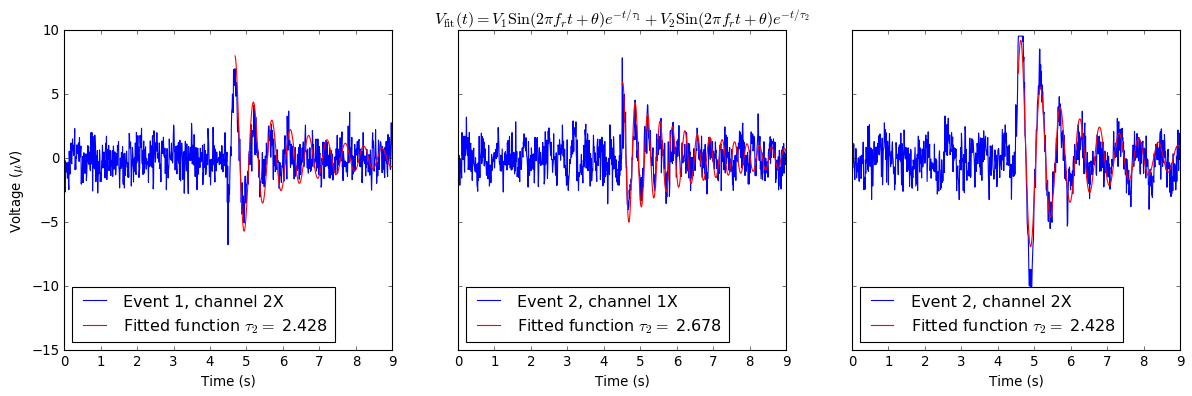

In [58]:
fig, ax = plt.subplots(1,3, figsize = (18,5),sharey=True)
ax[0].plot(tn,sig1_2X, label = 'Event 1, channel 2X')
ax[0].plot(tn[cutoff1_ch2:stop1_ch2],ideal_signal1_ch2,color = 'red', label = r'Fitted function $\tau_2 =$ %1.3f' % tau2_1ch2)

ax[1].plot(tn,sig2_1X, label = 'Event 2, channel 1X')
ax[1].plot(tn[cutoff2_ch1:stop2_ch1],ideal_signal2_ch1,color = 'red', label = r'Fitted function $\tau_2 =$ %1.3f' %tau2_2ch1)

ax[2].plot(tn,sig2_2X,label = 'Event 2, channel 2X')
ax[2].plot(tn[cutoff2_ch2:stop2_ch2],ideal_signal2_ch2,color = 'red',label = r'Fitted function $\tau_2 =$ %1.3f' % tau2_2ch2)

# ax[2].plot(tn[cutoff2_ch2:stop2_ch2],ideal_signal, color = 'orange')

ax[1].set_title(r'$V_\mathrm{fit}(t) = V_1\mathrm{Sin}(2\pi f_r t + \theta)e^{-t/\tau_1}+V_2\mathrm{Sin}(2\pi f_r t + \theta)e^{-t/\tau_2}$')

ax[0].legend(loc=0)
ax[1].legend(loc=0)
ax[2].legend(loc=0)
ax[0].set_ylabel('Voltage ($\mu$V)')
ax[0].set_xlabel('Time (s)')
ax[1].set_xlabel('Time (s)')
ax[2].set_xlabel('Time (s)')

pp = r'C:/Users/21958742/DarkMatterCentre Dropbox/William Campbell/PhD/High Frequency GW/Data Analysis/Significant Events/taufit2decay_ideal.pdf'
plt.savefig(pp, format='pdf', dpi=600)

Force the fit to actual decay constant $\tau_n$ to see how different it looks

In [59]:
def Vfit_forced_3B(t,V0,fr,theta):
    return V0*np.sin(2.0*np.pi*fr*t+theta)*np.exp(-t/tau0_3B)

def Vfit_forced_3C(t,V0,fr,theta):
    return V0*np.sin(2.0*np.pi*fr*t+theta)*np.exp(-t/tau0_3C)

In [60]:
#initial conditions for fit
ini_params1_ch2=[10.0,fr1_ch2,np.pi]
ini_params2_ch1=[10.0,fr2_ch1,np.pi]
ini_params2_ch2=[10.0,fr2_ch2,np.pi]

span = 600
stop1_ch2 = cutoff1_ch2 + span
stop2_ch1 = cutoff2_ch1 + span
stop2_ch2 = cutoff2_ch2 + span 

tau_fit1_ch2 = curve_fit(Vfit_forced_3B,tn[cutoff1_ch2:stop1_ch2]-tn[cutoff1_ch2],sig1_2X[cutoff1_ch2:stop1_ch2],p0=ini_params1_ch2)
tau_fit2_ch1 = curve_fit(Vfit_forced_3C,tn[cutoff2_ch1:stop2_ch1]-tn[cutoff2_ch1],sig2_1X[cutoff2_ch1:stop2_ch1],p0=ini_params2_ch1)
tau_fit2_ch2 = curve_fit(Vfit_forced_3B,tn[cutoff2_ch2:stop2_ch2]-tn[cutoff2_ch2],sig2_2X[cutoff2_ch2:stop2_ch2],p0=ini_params2_ch2)

fit_data1_ch2=Vfit_forced_3B(tn[cutoff1_ch2:stop1_ch2]-tn[cutoff1_ch2],tau_fit1_ch2[0][0],tau_fit1_ch2[0][1],tau_fit1_ch2[0][2])
fit_data2_ch1=Vfit_forced_3C(tn[cutoff2_ch1:stop2_ch1]-tn[cutoff2_ch1],tau_fit2_ch1[0][0],tau_fit2_ch1[0][1],tau_fit2_ch1[0][2])
fit_data2_ch2=Vfit_forced_3B(tn[cutoff2_ch2:stop2_ch2]-tn[cutoff2_ch2],tau_fit2_ch2[0][0],tau_fit2_ch2[0][1],tau_fit2_ch2[0][2])

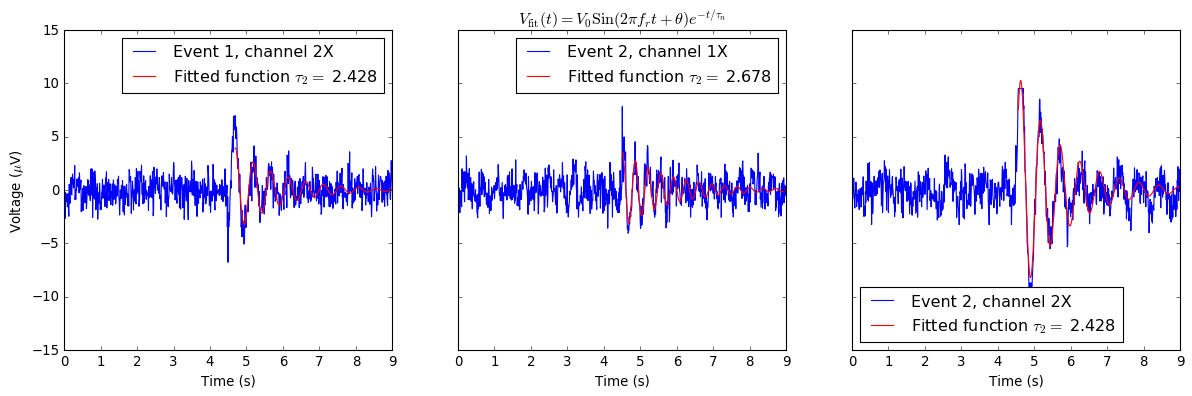

In [61]:
fig, ax = plt.subplots(1,3, figsize = (18,5),sharey=True)
ax[0].plot(tn,sig1_2X, label = 'Event 1, channel 2X')
ax[0].plot(tn[cutoff1_ch2:stop1_ch2],fit_data1_ch2,color = 'red', label = r'Fitted function $\tau_2 =$ %1.3f' % tau2_1ch2)

ax[1].plot(tn,sig2_1X, label = 'Event 2, channel 1X')
ax[1].plot(tn[cutoff2_ch1:stop2_ch1],fit_data2_ch1,color = 'red', label = r'Fitted function $\tau_2 =$ %1.3f' %tau2_2ch1)

ax[2].plot(tn,sig2_2X,label = 'Event 2, channel 2X')
ax[2].plot(tn[cutoff2_ch2:stop2_ch2],fit_data2_ch2,color = 'red',label = r'Fitted function $\tau_2 =$ %1.3f' % tau2_2ch2)

# ax[2].plot(tn[cutoff2_ch2:stop2_ch2],ideal_signal, color = 'orange')

ax[1].set_title(r'$V_\mathrm{fit}(t) = V_0\mathrm{Sin}(2\pi f_r t + \theta)e^{-t/\tau_n}$')

ax[0].legend(loc=0)
ax[1].legend(loc=0)
ax[2].legend(loc=0)
ax[0].set_ylabel('Voltage ($\mu$V)')
ax[0].set_xlabel('Time (s)')
ax[1].set_xlabel('Time (s)')
ax[2].set_xlabel('Time (s)')

pp = r'C:/Users/21958742/DarkMatterCentre Dropbox/William Campbell/PhD/High Frequency GW/Data Analysis/Significant Events/taufit_forced.pdf'
plt.savefig(pp, format='pdf', dpi=600)

In [62]:
tau0_5C

2.0292373636941443